In [1]:
import numpy as np
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  mean_squared_error,r2_score
from sklearn.model_selection import  train_test_split

In [2]:
diamonds = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv")

In [3]:
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
X = diamonds[["depth", "carat", "table"]]
y = diamonds["price"]


In [6]:
#Dividing dataset into  training and  testing sets 
# test_size = what is needed for  training and  testing
#random_state make it reproducable  for every  run- getting exact figures 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [7]:
# Fitting  the  multiple linear regression  model 

model = LinearRegression() 
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_test

40026    1110
10489    4796
4454     3619
20007    8545
30486     732
         ... 
53742    2723
53288     552
42099    1274
45166    1654
1516     2996
Name: price, Length: 10788, dtype: int64

In [9]:

print ("Intercept:", model.intercept_)
print ("Coeffiecient:", model.coef_)

#y = b0  + b1x1 + b2x2 + ......+  bnxn

Intercept: 13291.27602916348
Coeffiecient: [-155.95187797 7875.37847668 -104.58616105]


In [10]:
#model evaluation

y_pred = model.predict(X_test)
y_pred

array([1856.82907649, 3809.26832209, 4664.57726025, ..., 1297.56201082,
       1609.55268792, 4597.61635553], shape=(10788,))

In [11]:
mse = mean_squared_error( y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [12]:
mse

2331889.721465653

In [13]:
r2

0.8508106300695077

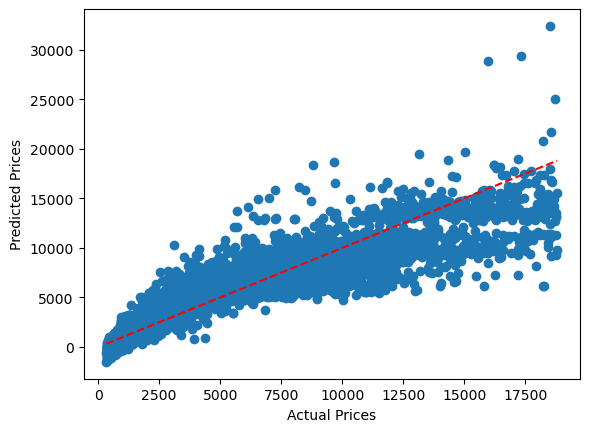

In [14]:
import matplotlib.pyplot as plt 

plt.scatter(y_test, y_pred)
#plt.scatter(y_test, y_pred, alpha=0.5) Add transparency to reduce overlap

# line of perfect prediction
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error

In [16]:
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

rmse


np.float64(1527.052625637261)

In [17]:
mae

999.0327626349081

In [18]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

Intercept: 13291.27602916348
Coefficients: [-155.95187797 7875.37847668 -104.58616105]
MSE: 2331889.721465653
RMSE: 1527.052625637261
MAE: 999.0327626349081
R2: 0.8508106300695077


### Dealing With Categorical Data 
- Using one-hot  encoding makes sure all the  categorical data is  transformed to  new binary(dummy use)
- Limitation - causes dummy variable trap which causes multicollinearity 

In [19]:
diamonds.head(2)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31


In [20]:
diamonds.color.value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [21]:
diamonds.cut.value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [22]:
features = [ 'color', 'cut', 'carat', 'depth', 'table']
target = 'price'

In [23]:
X = diamonds[features]
y= diamonds[target]

In [24]:
# we need  to convert  categorical features to numerical  features  using one-hot  encoding
# drop first to avoid multicollinearity 

X_encoded = pd.get_dummies(X, drop_first=True).astype(int)
X_encoded.head()

,carat,depth,table,color_E,color_F,color_G,color_H,color_I,color_J,cut_Good,cut_Ideal,cut_Premium,cut_Very Good
0,0,61,55,1,0,0,0,0,0,0,1,0,0
1,0,59,61,1,0,0,0,0,0,0,0,1,0
2,0,56,65,1,0,0,0,0,0,1,0,0,0
3,0,62,58,0,0,0,0,1,0,0,0,1,0
4,0,63,58,0,0,0,0,0,1,1,0,0,0


In [25]:
# Splitting  the data for  modelling 
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=7)
 
# Fitting the  Model  
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
model.intercept_

np.float64(1251.9443470578312)

In [27]:
model.coef_

array([ 6.15418654e+03, -2.97142345e+01,  2.38017805e+01, -1.04046908e+02,
        7.66512135e-01, -7.31286365e+01, -4.74390010e+02, -4.95401034e+02,
       -1.10120783e+03,  6.77846817e+02,  1.06321681e+03,  8.33667973e+02,
        9.84199209e+02])

In [28]:
diamonds.shape

(53940, 10)

In [29]:
import statsmodels.api as sm 
X_train = sm.add_constant(X_train)  # Adding constant for the  interceptor 
ols_model = sm.OLS(y_train, X_train).fit()
print ("OLS Summary :", ols_model.summary())

OLS Summary :                             OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     9252.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:17:22   Log-Likelihood:            -3.9038e+05
No. Observations:               43152   AIC:                         7.808e+05
Df Residuals:                   43138   BIC:                         7.809e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1251.9443    713.

In [30]:
df = pd.DataFrame({
    "age": [25, 28, 35, 30, 40, 23, 32, 29, 45, 27,
            38, 31, 26, 34, 41, 36, 24, 33, 39, 28],

    "experience": [2, 4, 10, 6, 15, 1, 8, 5, 20, 3,
                   12, 7, 2, 9, 16, 11, 1, 8, 14, 4],

    "education": ["Bachelors", "Masters", "PhD", "Masters", "PhD",
                  "Bachelors", "Masters", "Bachelors", "PhD", "Bachelors",
                  "Masters", "Masters", "Bachelors", "PhD", "PhD",
                  "Masters", "Bachelors", "Masters", "PhD", "Bachelors"],

    "city": ["Nairobi", "Nairobi", "Mombasa", "Kisumu", "Nairobi",
             "Kisumu", "Mombasa", "Nairobi", "Nairobi", "Mombasa",
             "Kisumu", "Nairobi", "Kisumu", "Mombasa", "Nairobi",
             "Nairobi", "Mombasa", "Kisumu", "Nairobi", "Nairobi"],

    "gender": ["Male", "Female", "Male", "Female", "Male",
               "Female", "Male", "Female", "Male", "Female",
               "Male", "Female", "Male", "Female", "Female",
               "Male", "Male", "Female", "Male", "Female"],

    "salary": [45000, 65000, 120000, 70000, 150000,
               35000, 85000, 60000, 180000, 50000,
               95000, 78000, 42000, 110000, 155000,
               100000, 38000, 82000, 140000, 58000]
})

print(df.head())

   age  experience  education     city  gender  salary
0   25           2  Bachelors  Nairobi    Male   45000
1   28           4    Masters  Nairobi  Female   65000
2   35          10        PhD  Mombasa    Male  120000
3   30           6    Masters   Kisumu  Female   70000
4   40          15        PhD  Nairobi    Male  150000


In [31]:
features = [ 'education', 'city', 'gender', 'age', 'experience']
target = 'salary'

In [32]:
X = df[features]
y = df[target]

In [33]:
# one hot encoding for  categorical variables
X_encoded = pd.get_dummies(X, drop_first=True).astype(int)
X_encoded

,age,experience,education_Masters,education_PhD,city_Mombasa,city_Nairobi,gender_Male
0,25,2,0,0,0,1,1
1,28,4,1,0,0,1,0
2,35,10,0,1,1,0,1
3,30,6,1,0,0,0,0
4,40,15,0,1,0,1,1
5,23,1,0,0,0,0,0
6,32,8,1,0,1,0,1
7,29,5,0,0,0,1,0
8,45,20,0,1,0,1,1
9,27,3,0,0,1,0,0


In [34]:
# Splitting  the data for modelling 
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y , test_size= 0.2, random_state=7)

#Fitting  the  model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
model.intercept_

np.float64(141521.82593927253)

In [36]:
model.coef_

array([-4737.72420364, 11124.71728595,  3696.56600804, 27728.03115033,
        2072.41207904,  2354.16511329, -1053.44020546])

In [37]:
X_train= sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     816.9
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           8.91e-11
Time:                        02:17:22   Log-Likelihood:                -140.95
No. Observations:                  16   AIC:                             297.9
Df Residuals:                       8   BIC:                             304.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.415e+05   3.58e+0

/home/mariam/miniconda3/envs/learn-env/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)
